**(a) Overview:** Support Vector Machines are supervised learning models used for classification and regression. SVMs aim to find the optimal hyperplane that best separates data points of different classes in a feature space. SVMs are considered linear separators because they aim to find the optimal hyperplane that separates data points of different classes using a linear decision boundary. SVMs use the kernel trick to project data into a higher-dimensional space where a linear separator might exist. In the dual form of the SVM optimization problem, the classifier makes predictions using only dot products between data points. Instead of working directly with the original input features, it evaluates how similar a new data point is to each of the training points by measuring their geometric alignment. This similarity is calculated using a function called a kernel, which effectively replaces the traditional dot product. The kernel allows the SVM to operate in a higher-dimensional space without explicitly transforming the data into that space.

In [10]:
# The polynomial kernel maps the input features into a higher-dimensional space using polynomial combinations of features.
# K(x,x ′)=exp(−γ∥x−x ′∥ 2

import numpy as np

def polynomial_kernel(x, x_prime, gamma=1, r=1, degree=2):
    """
    Computes the polynomial kernel between two vectors.

    Parameters:
    - x: First input vector (1D numpy array)
    - x_prime: Second input vector (1D numpy array)
    - gamma: Scaling parameter (default 1)
    - r: Constant term added to the dot product (default 1)
    - degree: Degree of the polynomial (default 2)

    Returns:
    - Kernel value (scalar)
    """
    dot_product = np.dot(x, x_prime)
    return (gamma * dot_product + r) ** degree


In [11]:
x = np.array([2, 3])
x_prime = np.array([2, 3])

k_poly = polynomial_kernel(x, x_prime)
print("Polynomial Kernel Value:", k_poly)


Polynomial Kernel Value: 196


In [12]:
# Radial Basis Function (RBF) Kernel The RBF kernel measures the distance between two points and returns a value close to 1 if they are similar (close together), and close to 0 if they are
# different (far apart).
# K(x,x ′)=exp(−γ∥x−x′∥2)

def rbf_kernel(x, x_prime, gamma=0.5):
    """
    Computes the RBF (Gaussian) kernel between two vectors.

    Parameters:
    - x: First input vector (1D numpy array)
    - x_prime: Second input vector (1D numpy array)
    - gamma: Controls the smoothness/scale of the kernel (default 0.5)

    Returns:
    - Kernel value (scalar)
    """
    distance_squared = np.linalg.norm(x - x_prime) ** 2
    return np.exp(-gamma * distance_squared)


In [13]:
x = np.array([2, 3])
x_prime = np.array([2, 3])

k_rbf = rbf_kernel(x, x_prime)
print("RBF Kernel Value:", k_rbf)


RBF Kernel Value: 1.0


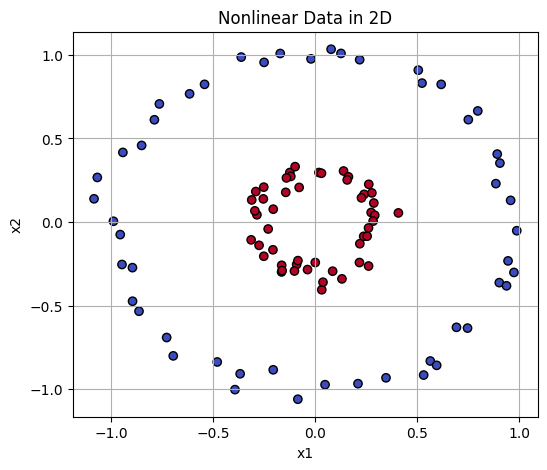

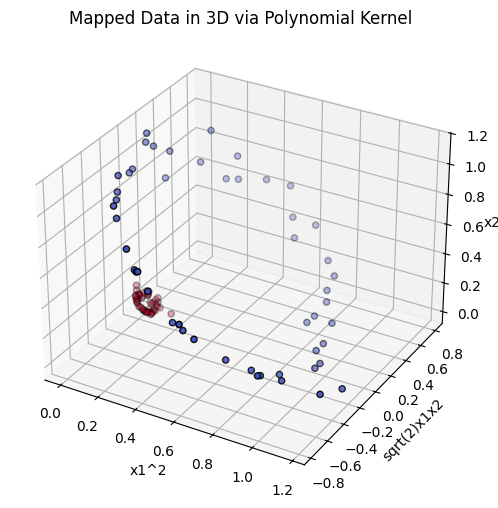

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from mpl_toolkits.mplot3d import Axes3D

# Generate toy data (nonlinear in 2D)
X, y = make_circles(n_samples=100, factor=0.3, noise=0.05)

# Plot in 2D
plt.figure(figsize=(6, 5))
plt.title("Nonlinear Data in 2D")
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolors='k')
plt.xlabel('x1')
plt.ylabel('x2')
plt.grid(True)
plt.show()

# Manually apply polynomial transformation to 3D: (x1^2, sqrt(2)*x1*x2, x2^2)
X_poly = np.array([
    [x[0]**2, np.sqrt(2)*x[0]*x[1], x[1]**2] for x in X
])

# Plot in 3D
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_poly[:, 0], X_poly[:, 1], X_poly[:, 2], c=y, cmap='coolwarm', edgecolors='k')
ax.set_title("Mapped Data in 3D via Polynomial Kernel")
ax.set_xlabel('x1^2')
ax.set_ylabel('sqrt(2)x1x2')
ax.set_zlabel('x2^2')
plt.show()


**(b) Data Prep:** The dataset used is from the Low Value Care FY23 Public Data report. It includes information on service type, region, payer type, and associated spending. Each row represents a healthcare service entry for a given payer and year. The goal is to classify whether the low-value care spending is above the median threshold, making this a binary classification task.
The Training and test data must be disjointed because in supervised learning, model performance is evaluated on unseen data. If the same data points appear in both the training and testing sets, the model could memorize patterns and overfitting will occur, giving an inflated sense of accuracy. Ensuring the sets are disjoint preserves the integrity of the evaluation.
To evaluate the model's performance, the dataset was split into two parts, the Training Set (80%), used to train the SVM model, and the Testing Set (20%), used to evaluate the model's performance on unseen data. This was done using sklearn.model_selection.train_test_split().


In [14]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [15]:
# Load dataset
file_path = '/content/FY23_Public Data_Low Value Care (1).xlsx'
df = pd.read_excel(file_path)
df = pd.read_excel(file_path, skiprows=2)

# Drop empty rows or columns
df = df.dropna(how='all').dropna(axis=1, how='all')

# View of the data
print("First few rows of the dataset:")
print(df.head())
print("\nColumn names:", df.columns)

First few rows of the dataset:
                     Unnamed: 2  Unnamed: 3 Unnamed: 4  \
0  Division of Insurance Region  Payer Type       Year   
1                       Boulder        CHP+       2017   
2                       Boulder        CHP+       2017   
3                       Boulder        CHP+       2017   
4                       Boulder        CHP+       2017   

                                          Unnamed: 5         Unnamed: 6  \
0                                       Service Type  Total LV Spending   
1                         25-OH-Vitamin D Deficiency                329   
2                                Annual Resting EKGs                  0   
3  Antibiotics for Acute Upper Respiratory and Ea...                714   
4          Antibiotics for Adenoviral Conjunctivitis                 18   

                         Unnamed: 7                  Unnamed: 8  
0  Total Spending on Necessary Care  Total LV Services (Volume)  
1                               246  

In [16]:
# Clean and convert columns
df.columns = [
    "Region", "Payer_Type", "Year", "Service_Type",
    "Total_LV_Spending", "Total_Necessary_Spending", "LV_Volume"
]

# Remove rows where LV_Volume is '*'
df = df[df["LV_Volume"] != "*"].copy()

# Convert numeric columns
df["Total_LV_Spending"] = pd.to_numeric(df["Total_LV_Spending"], errors='coerce')
df["Total_Necessary_Spending"] = pd.to_numeric(df["Total_Necessary_Spending"], errors='coerce')
df["LV_Volume"] = pd.to_numeric(df["LV_Volume"], errors='coerce')

# Drop rows with missing values
df = df.dropna(subset=["Total_LV_Spending", "Total_Necessary_Spending", "LV_Volume"])


In [ ]:
# target variables
median_spend = df["Total_LV_Spending"].median()
df["High_LV_Spend"] = (df["Total_LV_Spending"] > median_spend).astype(int)

# Encode categorical variables
label_encoders = {}
for col in ["Region", "Payer_Type", "Service_Type"]:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

# features (X) and target (y)
X = df[["Region", "Payer_Type", "Year", "Service_Type", "Total_Necessary_Spending", "LV_Volume"]]
y = df["High_LV_Spend"]

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [ ]:
# Output
print(" Data loaded and preprocessed.")
print("X_train shape:", X_train.shape)
print("y_train distribution:\n", y_train.value_counts())

 Data loaded and preprocessed.
X_train shape: (6014, 6)
y_train distribution:
 High_LV_Spend
0    3013
1    3001
Name: count, dtype: int64


In [17]:
# View of Cleaned Dataset
df.head()


,Region,Payer_Type,Year,Service_Type,Total_LV_Spending,Total_Necessary_Spending,LV_Volume
2,Boulder,CHP+,2017,Annual Resting EKGs,0.0,12771.0,0.0
3,Boulder,CHP+,2017,Antibiotics for Acute Upper Respiratory and Ea...,714.0,0.0,28.0
5,Boulder,CHP+,2017,Cardiac Stress Testing,0.0,1451.0,0.0
6,Boulder,CHP+,2017,Cervical Cancer Screening for Women,0.0,2608.0,0.0
9,Boulder,CHP+,2017,Dexa,0.0,10.0,0.0


In [20]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Load and clean the Excel file
file_path = '/content/FY23_Public Data_Low Value Care (1).xlsx'
df = pd.read_excel(file_path, skiprows=2)
df = df.dropna(how='all').dropna(axis=1, how='all')
df.columns = [
    "Region", "Payer_Type", "Year", "Service_Type",
    "Total_LV_Spending", "Total_Necessary_Spending", "LV_Volume"
]
df = df[df["LV_Volume"] != "*"].copy()
df["Total_LV_Spending"] = pd.to_numeric(df["Total_LV_Spending"], errors='coerce')
df["Total_Necessary_Spending"] = pd.to_numeric(df["Total_Necessary_Spending"], errors='coerce')
df["LV_Volume"] = pd.to_numeric(df["LV_Volume"], errors='coerce')
df = df.dropna(subset=["Total_LV_Spending", "Total_Necessary_Spending", "LV_Volume"])

# Create classification target
median_spend = df["Total_LV_Spending"].median()
df["High_LV_Spend"] = (df["Total_LV_Spending"] > median_spend).astype(int)

# Encode categorical columns
label_encoders = {}
for col in ["Region", "Payer_Type", "Service_Type"]:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

# Define features and target
X = df[["Region", "Payer_Type", "Year", "Service_Type", "Total_Necessary_Spending", "LV_Volume"]]
y = df["High_LV_Spend"]

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


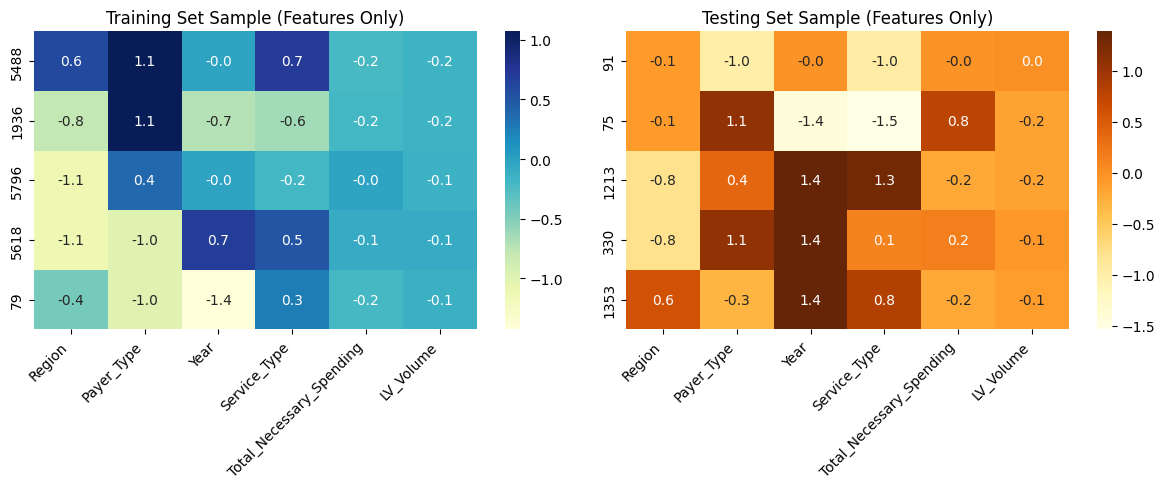

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Create a small sample from the cleaned dataset
sample_df = df.sample(10, random_state=42)

# Create readable train/test sample views
train_sample = pd.DataFrame(X_train, columns=["Region", "Payer_Type", "Year", "Service_Type", "Total_Necessary_Spending", "LV_Volume"])
train_sample["High_LV_Spend"] = y_train.values
train_sample = train_sample.sample(5, random_state=1)

test_sample = pd.DataFrame(X_test, columns=["Region", "Payer_Type", "Year", "Service_Type", "Total_Necessary_Spending", "LV_Volume"])
test_sample["High_LV_Spend"] = y_test.values
test_sample = test_sample.sample(5, random_state=1)

# Plot heatmaps for train and test sets
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(train_sample.iloc[:, :-1], annot=True, fmt=".1f", cmap="YlGnBu", ax=axs[0])
axs[0].set_title("Training Set Sample (Features Only)")
axs[0].set_xticklabels(train_sample.columns[:-1], rotation=45, ha='right')

sns.heatmap(test_sample.iloc[:, :-1], annot=True, fmt=".1f", cmap="YlOrBr", ax=axs[1])
axs[1].set_title("Testing Set Sample (Features Only)")
axs[1].set_xticklabels(test_sample.columns[:-1], rotation=45, ha='right')

plt.tight_layout()
plt.show()

# Save a sample of the original cleaned dataset
sample_df.to_csv("sample_for_svm.csv", index=False)


In [22]:
# Save 5-row training and testing samples to CSV
train_sample.to_csv("train_sample_svm.csv", index=False)
test_sample.to_csv("test_sample_svm.csv", index=False)


**Data Preparation and Train-Test Split for SVM:** The dataset was first cleaned to include only numeric and labeled records with valid values for low-value care spending and service volume. A new binary target variable, High_LV_Spend, was created to indicate whether a record’s total low-value spending exceeded the dataset’s median value. This transformation allowed the classification task to be framed as a supervised binary classification problem.

To evaluate model performance fairly, the data was divided into training and testing sets, ensuring they were completely disjoint. This separation is essential in supervised learning: the training set is used to build the model, while the testing set measures its ability to generalize to new, unseen data. Allowing overlap between the sets would lead to data leakage, artificially high accuracy, and unreliable evaluation metrics.
Support Vector Machines (SVMs) require input data to be both numerical and labeled, as they rely on geometric operations such as dot products to compute distances and margins between data points. These calculations cannot be performed on raw categorical or unlabeled data. Additionally, because SVMs are supervised models, they must be trained using examples with known class labels in order to learn an effective decision boundary.

 Accuracy Score: 0.7280585106382979

 Classification Report:
               precision    recall  f1-score   support

           0       0.71      0.76      0.74       746
           1       0.75      0.70      0.72       758

    accuracy                           0.73      1504
   macro avg       0.73      0.73      0.73      1504
weighted avg       0.73      0.73      0.73      1504



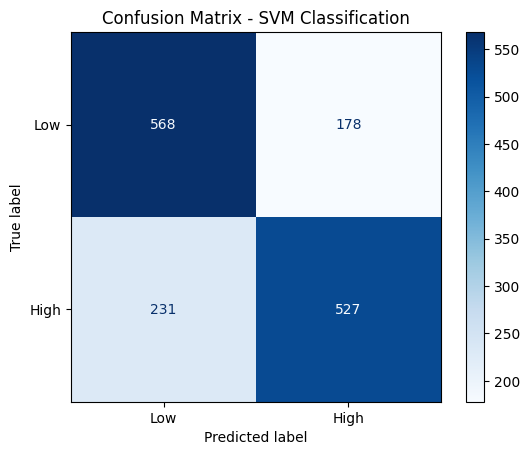

In [23]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import pandas as pd
import matplotlib.pyplot as plt

# Train the SVM model (RBF kernel)
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm_model.fit(X_train, y_train)

# Predict on test data
y_pred = svm_model.predict(X_test)

# Generate evaluation results
print(" Accuracy Score:", accuracy_score(y_test, y_pred))
print("\n Classification Report:\n", classification_report(y_test, y_pred))

# Plot the confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Low", "High"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - SVM Classification")
plt.show()


**Results (d):** The Support Vector Machine classifier achieved an accuracy of approximately 73%, correctly predicting 1,095 out of 1,504 test cases. This represents a strong baseline, particularly given the relatively balanced distribution between high and low-spending classes.

For Class 0 (Low Low-Value Spending), the model demonstrated high recall, meaning it successfully identified most low-spending cases. However, it showed a modest rate of false positives, labeling some actual low spenders as high spenders. In contrast, Class 1 (High Low-Value Spending) was predicted with slightly higher precision, though the model missed a number of high-spending cases, reflected in a lower recall for this class.

The confusion matrix highlights this balance. The model correctly identified 568 low-spending cases (true negatives) and 527 high-spending cases (true positives). However, it also generated 178 false positives (low spenders misclassified as high) and 231 false negatives (high spenders misclassified as low).

The macro and weighted averages of precision, recall, and F1 score indicate a generally balanced performance across both classes. This suggests the model is not overly biased toward either outcome, which is ideal in balanced classification tasks. However, the relatively higher number of false negatives for high spenders suggests a potential area for model improvement. If minimizing missed high-spending cases is critical for policy or operational reasons, future iterations of the model could incorporate adjusted class weights, hyperparameter tuning, or alternative kernel functions to optimize performance further.


In [24]:
# Preprocessing block to restore variables
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Load and clean dataset again
file_path = '/content/FY23_Public Data_Low Value Care (1).xlsx'
df = pd.read_excel(file_path, skiprows=2)
df = df.dropna(how='all').dropna(axis=1, how='all')
df.columns = [
    "Region", "Payer_Type", "Year", "Service_Type",
    "Total_LV_Spending", "Total_Necessary_Spending", "LV_Volume"
]
df = df[df["LV_Volume"] != "*"].copy()
df["Total_LV_Spending"] = pd.to_numeric(df["Total_LV_Spending"], errors='coerce')
df["Total_Necessary_Spending"] = pd.to_numeric(df["Total_Necessary_Spending"], errors='coerce')
df["LV_Volume"] = pd.to_numeric(df["LV_Volume"], errors='coerce')
df = df.dropna(subset=["Total_LV_Spending", "Total_Necessary_Spending", "LV_Volume"])

# Create target
df["High_LV_Spend"] = (df["Total_LV_Spending"] > df["Total_LV_Spending"].median()).astype(int)

# Encode categorical
for col in ["Region", "Payer_Type", "Service_Type"]:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

# Features and target
X = df[["Region", "Payer_Type", "Year", "Service_Type", "Total_Necessary_Spending", "LV_Volume"]]
y = df["High_LV_Spend"]

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


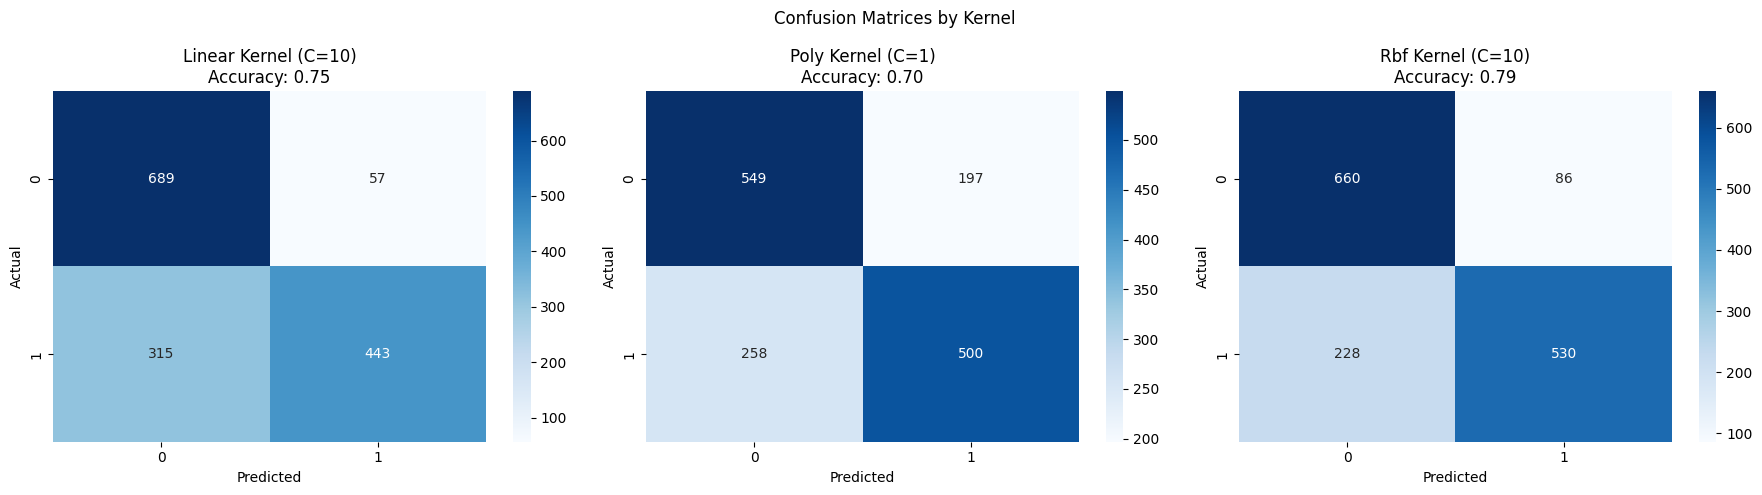

,Kernel,Cost,Accuracy
8,rbf,10.0,0.7912
2,linear,10.0,0.7527
7,rbf,1.0,0.7281
1,linear,1.0,0.7114
4,poly,1.0,0.6975
5,poly,10.0,0.6935
3,poly,0.1,0.6662
6,rbf,0.1,0.6636
0,linear,0.1,0.6416


In [25]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Kernels and cost values to evaluate
kernels = ['linear', 'poly', 'rbf']
cost_values = [0.1, 1, 10]

results = []

for kernel in kernels:
    for cost in cost_values:
        try:
            model = SVC(kernel=kernel, C=cost, gamma='scale', degree=3, random_state=42)
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)

            acc = accuracy_score(y_test, y_pred)
            cm = confusion_matrix(y_test, y_pred)

            results.append({
                'kernel': kernel,
                'cost': cost,
                'accuracy': acc,
                'confusion_matrix': cm
            })
        except Exception as e:
            print(f" Error with kernel={kernel}, C={cost}: {e}")

# Plot confusion matrix for best model from each kernel
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, kernel in enumerate(kernels):
    top = max([r for r in results if r['kernel'] == kernel], key=lambda x: x['accuracy'])
    sns.heatmap(top['confusion_matrix'], annot=True, fmt='d', cmap='Blues', ax=axes[i])
    axes[i].set_title(f"{kernel.capitalize()} Kernel (C={top['cost']})\nAccuracy: {top['accuracy']:.2f}")
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("Actual")

plt.suptitle("Confusion Matrices by Kernel")
plt.tight_layout()
plt.show()

# Show accuracy comparison table
summary_df = pd.DataFrame([{
    'Kernel': r['kernel'],
    'Cost': r['cost'],
    'Accuracy': round(r['accuracy'], 4)
} for r in results])

summary_df.sort_values(by='Accuracy', ascending=False)


**(d) Results:** The radial basis function (RBF) kernel with C = 10 delivered the strongest overall performance, achieving an accuracy of 79.1%. It outperformed both the linear and polynomial kernels, indicating that the decision boundary in this classification task is likely nonlinear. While the linear kernel (C = 10) was simpler and still relatively effective, it misclassified a larger portion of high-spending examples. The polynomial kernel performed the weakest overall in this configuration, suggesting that it may not be well-suited to the patterns present in this dataset.

This SVM analysis demonstrates that the RBF kernel was best at capturing the complex relationships between features, achieving a classification accuracy of nearly 79%. These findings suggest that low-value care spending patterns are not linearly separable, and more flexible models like RBF are required to accurately classify them.




**(e) Conclusion:** This analysis used Support Vector Machines (SVMs) to classify whether low-value healthcare spending exceeded the median, based on structured features such as region, payer type, service type, necessary care spending, and service volume. Three kernel types linear, polynomial, and radial basis function were evaluated across multiple regularization (C) values. The RBF kernel with C = 10 achieved the highest accuracy at 79.1%, indicating that the relationship between input features and spending classification is likely nonlinear and benefits from flexible, high-dimensional decision boundaries.

While the linear kernel offered computational simplicity, it underperformed in identifying high-spending cases. The polynomial kernel showed the weakest performance overall, likely due to its sensitivity to parameter tuning and increased model complexity. These results suggest that SVMs with nonlinear kernels like RBF are well suited for modeling healthcare cost data, where patterns often defy linear separability.

The classification model effectively identified payer-region combinations likely to exceed median low-value care spending, offering potential applications in targeted audits, quality improvement efforts, and health system policy design. Future work could expand the feature set to include provider characteristics or demographic variables, implement cross-validation for improved generalizability, and compare SVM performance to alternative classifiers such as decision trees or ensemble models.


****